## Setup

In [1]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from src.functions import scatter_plot_fn

## Load data

In [2]:
crbn_binding_data = pd.read_excel('data/mmc3.xlsx', skiprows=1)
crbn_binding_data.head()

,Cxsmiles,Smiles,Catalog ID,"V, µL","Conc, mM",Formula,MW,Purity,Salt smiles,Salt_name,...,"Stereochem,data","Geometric,isomer",Chemical name,ClogP,logS,HBD,HBA,TPSA,RotBonds,FP Response
0,CC1(C)CC(=O)NC=2C=CC(=CC21)S(=O)(=O)NC=3C=CC=4...,CC1(C)CC(=O)NC=2C=CC(=CC21)S(=O)(=O)NC=3C=CC=4...,Z5000147527,10,10,C24H24N4O6S,496.5356,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",1.614,-4.421,3,6,141.75,3,63.85
1,CCN1N=CC=C1S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C2)C4C...,CCN1N=CC=C1S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C2)C4C...,Z5000147208,10,10,C18H19N5O5S,417.4390,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",0.024,-3.102,2,6,130.47,4,65.80
2,CC=1C=CC(=C2C=CC=CC12)S(=O)(=O)NC=3C=CC=4C(=O)...,CC=1C=CC(=C2C=CC=CC12)S(=O)(=O)NC=3C=CC=4C(=O)...,Z5000146412,10,10,C24H21N3O5S,463.5056,96.81,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",2.773,-6.251,2,5,112.65,3,60.35
3,O=C1N(CC=2C=C(NS(=O)(=O)C3=C(C#N)SC=4C=CC=CC34...,O=C1N(CC=2C=C(NS(=O)(=O)C3=C(C#N)SC=4C=CC=CC34...,Z5000147289,10,10,C22H16N4O5S2,480.5162,98.53,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"2-cyano-N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2...",2.107,-5.659,2,6,136.44,3,64.70
4,CCCC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C...,CCCC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C...,Z5000145522,10,10,C22H23N3O5S,441.5001,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",2.657,-5.483,2,5,112.65,5,61.15


## Transform smiles to fingerprints (Morgan, radius 2, n_bits 2048)

In [3]:
morgan_gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp_list(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 2048
    fp = morgan_gen.GetFingerprint(mol)
    return(list(fp))

ai_data = pd.DataFrame(crbn_binding_data["Smiles"].apply(smiles_to_fp_list).tolist())
ai_data = pd.concat([ai_data, crbn_binding_data[["Catalog ID", "FP Response"]].rename(columns={"Catalog ID": "id", "FP Response": "binding"}) ], axis=1)
ai_data.head()

,0,1,2,3,4,5,6,7,8,9,...,2040,2041,2042,2043,2044,2045,2046,2047,id,binding
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147527,63.85
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147208,65.80
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000146412,60.35
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147289,64.70
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000145522,61.15


## Split data (80% train test split)

In [4]:
X = ai_data.iloc[:, :-2]
y = ai_data["binding"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## XGBoost

#### training

In [5]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

In [6]:
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
model.save_model("model.json")

#### Prediction

In [8]:
y_pred = model.predict(X_test)

#### Visualization

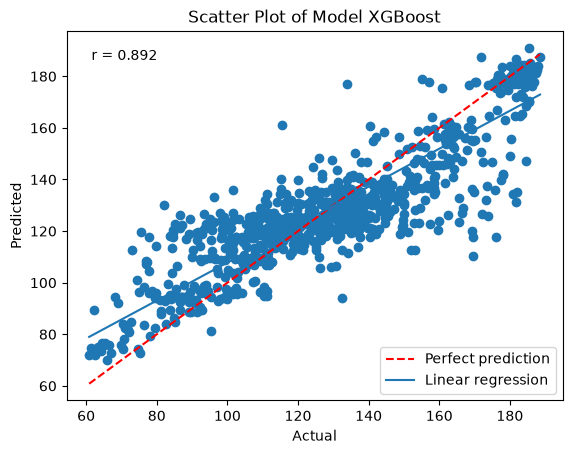

In [9]:
scatter_plot_fn(y_test, y_pred, "XGBoost")